# pMTJ data retention and barrier leakage

NumPy physics, matplotlib figures. Two questions about a perpendicular magnetic
tunnel junction:

1. **Retention** — how long does a written bit survive thermal agitation?
   Néel–Arrhenius: $K_\mathrm{eff}=K_{u1}-\tfrac{1}{2}\mu_0M_s^2$,
   $\Delta=K_\mathrm{eff}V/k_BT$, $\tau=\tau_0e^{\Delta}$, $P_\mathrm{flip}=1-e^{-t/\tau}$.
2. **Data leak** — how much current tunnels through the MgO barrier at rest?
   Tsu–Esaki over the exact 1D effective-mass barrier:
   $J=\dfrac{q\,m^*k_BT}{2\pi^2\hbar^3}\displaystyle\int T(E)\,N(E)\,\mathrm{d}E$.

## What this is, and what it is not

Everything here is an **analytical model**. It is single-domain and single-band,
transport is zero-temperature apart from the supply function, and the barrier
height, tunneling effective mass, and Fermi level are **placeholders** rather
than reviewed values. Nothing is fitted to a measured device, so no number here
is a product retention rating or a measured leakage spec.

The magnetization *dynamics* are not modelled here. Those are integrated by the
`python_micromagnetic` 64×32×1 mesh solver in the Twin app, which is a separate
computation with its own honesty labels.

Every function is imported from `backend/app/physics/device_chain.py`, which is
pinned by `backend/tests/test_device_chain.py` against golden values exported
from the JavaScript the web dashboard uses. The last cell re-checks that
agreement, so these figures cannot silently disagree with the app.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start: Path) -> Path:
    """Work no matter which directory Jupyter was launched from."""
    for candidate in [start, *start.parents]:
        if (candidate / "backend" / "app" / "physics").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root from %s" % start)


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT / "backend") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "backend"))

FIGURE_DIR = REPO_ROOT / "notebooks" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

from app.physics.device_chain import (  # noqa: E402  (import needs sys.path above)
    BOLTZMANN,
    HONESTY,
    MU_0,
    SECONDS_PER_YEAR,
    TEN_YEAR_SECONDS,
    delta_for_retention,
    effective_anisotropy,
    free_layer_volume_m3,
    leakage_sweep,
    retention_from_delta,
    thermal_stability,
    transmission,
    tunnel_current_density,
)

# Dark scientific-instrument palette, matching the Twin dashboard.
INK = "#e2e8f0"
MUTED = "#94a3b8"
GRID = "#1e293b"
ACCENT = "#60a5fa"
WARN = "#fbbf24"
BAD = "#f87171"
GOOD = "#86efac"

mpl.rcParams.update({
    "figure.facecolor": "#05070a",
    "figure.edgecolor": "#05070a",
    "savefig.facecolor": "#05070a",
    "axes.facecolor": "#070b10",
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.framealpha": 0.0,
    "legend.fontsize": 9,
    "legend.labelcolor": INK,
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "savefig.bbox": "tight",
    "lines.linewidth": 1.8,
    "font.size": 10,
    "hatch.color": BAD,
    "hatch.linewidth": 0.7,
})


def save(fig: mpl.figure.Figure, name: str) -> Path:
    """Write a figure next to the notebook and report where it landed."""
    path = FIGURE_DIR / name
    fig.savefig(path)
    print("saved %s" % path.relative_to(REPO_ROOT))
    return path


DELTA_TEN_YEAR = delta_for_retention(TEN_YEAR_SECONDS)
print("numpy %s / matplotlib %s" % (np.__version__, mpl.__version__))
print("Delta needed for 10-year retention: %.2f" % DELTA_TEN_YEAR)
print(HONESTY)

numpy 2.0.2 / matplotlib 3.9.4
Delta needed for 10-year retention: 40.29
Analytical device chain: Neel-Arrhenius retention, Tsu-Esaki tunnel current, and Julliere magnetoresistance. Single-domain and single-band assumptions. Barrier height, effective mass, and Fermi level are placeholders. Not calibrated to a measured device.


## Device parameters

Geometry and material constants follow the reference pMTJ recorded in
`backend/app/physics/reference_pmtj.py`, where every value is flagged
`UNVALIDATED_DEFAULT`. The barrier numbers (height, effective mass, Fermi level)
are placeholders that fix the shape of the tunneling curves; treat them as a
worked example, not as MgO.

The thin-film demagnetizing term matters here. A perpendicular easy axis pays
$\tfrac{1}{2}\mu_0M_s^2$, which at $M_s=1.0\times10^6$ A/m is
$6.28\times10^5$ J/m³ — comparable to $K_{u1}$ itself, so it consumes most of
the nominal anisotropy.

In [2]:
# Free layer (the mesh solver models this region; here it only sets the volume)
DIAMETER_NM = 40.0
FREE_THICKNESS_NM = 1.2
MS_A_PER_M = 1.0e6
KU1_J_PER_M3 = 8.0e5
TEMPERATURE_K = 300.0

# MgO barrier (placeholders)
BARRIER_THICKNESS_NM = 1.0
BARRIER_HEIGHT_EV = 1.2
EFFECTIVE_MASS_RATIO = 0.4
FERMI_EV = 0.8
READ_BIAS_V = 0.1

volume_m3 = free_layer_volume_m3(DIAMETER_NM, DIAMETER_NM, FREE_THICKNESS_NM, shape="ellipse")
anisotropy = effective_anisotropy(KU1_J_PER_M3, MS_A_PER_M, easy_axis="perpendicular")
stability = thermal_stability(anisotropy["effective_j_per_m3"], volume_m3, TEMPERATURE_K)
retention = retention_from_delta(stability["delta"])

print("free-layer volume        %.4g m^3  (%.1f nm ellipse x %.1f nm)"
      % (volume_m3, DIAMETER_NM, FREE_THICKNESS_NM))
print("K_u1                     %.4g J/m^3" % anisotropy["anisotropy_j_per_m3"])
print("mu_0 M_s^2 / 2           %.4g J/m^3   <- shape penalty" % anisotropy["shape_term_j_per_m3"])
print("K_eff                    %.4g J/m^3   (%.0f%% of K_u1 survives)"
      % (anisotropy["effective_j_per_m3"],
         100.0 * anisotropy["effective_j_per_m3"] / anisotropy["anisotropy_j_per_m3"]))
print("E_b                      %.4g J = %.3f eV"
      % (stability["energy_barrier_j"], stability["energy_barrier_ev"]))
print("Delta = E_b / kT         %.2f  (need %.2f for 10 years)"
      % (stability["delta"], DELTA_TEN_YEAR))
print("tau                      %.4g s = %.3g years"
      % (retention["tau_seconds"], retention["tau_years"]))
print("P_flip over 10 years     %.4g" % retention["flip_probability"])
print("meets 10-year retention  %s" % bool(retention["meets_ten_year_retention"]))

leak = tunnel_current_density(
    barrier_thickness_nm=BARRIER_THICKNESS_NM,
    barrier_height_ev=BARRIER_HEIGHT_EV,
    effective_mass_ratio=EFFECTIVE_MASS_RATIO,
    bias_volts=READ_BIAS_V,
    temperature_k=TEMPERATURE_K,
    fermi_ev=FERMI_EV,
)
junction_area_m2 = (np.pi / 4.0) * (DIAMETER_NM * 1e-9) ** 2
print()
print("barrier regime           %s (top is %.2f eV above E_F)"
      % (leak["regime"], leak["barrier_above_fermi_ev"]))
print("J_leak at %.2f V         %.4g A/m^2" % (READ_BIAS_V, leak["current_density_a_per_m2"]))
print("I_leak per junction      %.4g A" % (leak["current_density_a_per_m2"] * junction_area_m2))

free-layer volume        1.508e-24 m^3  (40.0 nm ellipse x 1.2 nm)
K_u1                     8e+05 J/m^3
mu_0 M_s^2 / 2           6.283e+05 J/m^3   <- shape penalty
K_eff                    1.717e+05 J/m^3   (21% of K_u1 survives)
E_b                      2.589e-19 J = 1.616 eV
Delta = E_b / kT         62.50  (need 40.29 for 10 years)
tau                      1.397e+18 s = 4.43e+10 years
P_flip over 10 years     2.259e-10
meets 10-year retention  True

barrier regime           tunneling (top is 0.40 eV above E_F)
J_leak at 0.10 V         8.642e+10 A/m^2
I_leak per junction      0.0001086 A


## Retention

$\tau=\tau_0e^{\Delta}$ with $\tau_0=1$ ns. The exponential is unforgiving: a few
$k_BT$ of barrier is the difference between milliseconds and millennia, which is
why $\Delta$ rather than $E_b$ is the number that gets quoted.

`retention_from_delta` holds $\ln\tau$ rather than $\tau$, because $e^{\Delta}$
overflows a float64 near $\Delta\approx710$. Beyond that it reports an infinite
dwell time instead of a NaN.

saved notebooks/figures/retention_dwell_time.png


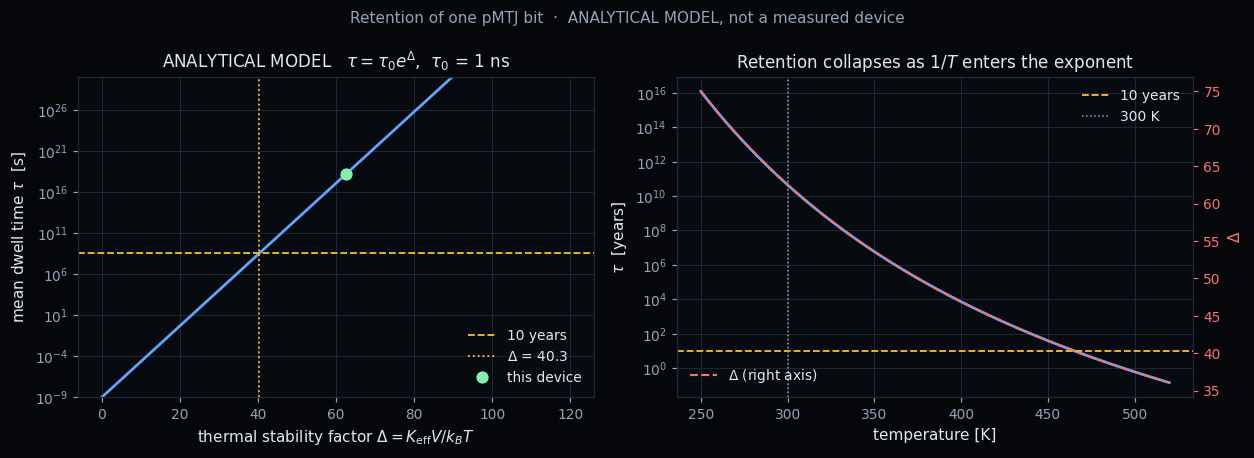

tau falls to the 10-year mark at T = 465 K (check: tau = 10.00 years there)
that crossing is within the plotted range


In [3]:
delta_axis = np.linspace(0.0, 120.0, 600)
sweep = retention_from_delta(delta_axis)

temperature_axis = np.linspace(250.0, 520.0, 400)
stability_vs_t = thermal_stability(anisotropy["effective_j_per_m3"], volume_m3, temperature_axis)
retention_vs_t = retention_from_delta(stability_vs_t["delta"])

fig, (ax_delta, ax_temp) = plt.subplots(1, 2, figsize=(11.5, 4.2))

ax_delta.semilogy(delta_axis, sweep["tau_seconds"], color=ACCENT)
ax_delta.axhline(TEN_YEAR_SECONDS, color=WARN, ls="--", lw=1.2, label="10 years")
ax_delta.axvline(DELTA_TEN_YEAR, color=WARN, ls=":", lw=1.2,
                 label=r"$\Delta$ = %.1f" % DELTA_TEN_YEAR)
ax_delta.plot([stability["delta"]], [retention["tau_seconds"]], "o", color=GOOD, ms=7,
              label="this device")
ax_delta.set_xlabel(r"thermal stability factor $\Delta = K_\mathrm{eff}V / k_BT$")
ax_delta.set_ylabel(r"mean dwell time $\tau$  [s]")
ax_delta.set_title(r"ANALYTICAL MODEL   $\tau=\tau_0e^{\Delta}$,  $\tau_0$ = 1 ns")
ax_delta.set_ylim(1e-9, 1e30)
ax_delta.legend(loc="lower right")

ax_temp.semilogy(temperature_axis, retention_vs_t["tau_years"], color=ACCENT)
ax_temp.axhline(10.0, color=WARN, ls="--", lw=1.2, label="10 years")
ax_temp.axvline(TEMPERATURE_K, color=MUTED, ls=":", lw=1.0, label="300 K")
ax_temp.set_xlabel("temperature [K]")
ax_temp.set_ylabel(r"$\tau$  [years]")
ax_temp.set_title(r"Retention collapses as $1/T$ enters the exponent")
ax_temp.legend(loc="upper right")

twin = ax_temp.twinx()
twin.plot(temperature_axis, stability_vs_t["delta"], color=BAD, lw=1.4, ls="--",
          label=r"$\Delta$ (right axis)")
twin.legend(loc="lower left")
twin.set_ylabel(r"$\Delta$", color=BAD)
twin.tick_params(axis="y", colors=BAD)
twin.grid(False)

fig.suptitle("Retention of one pMTJ bit  ·  ANALYTICAL MODEL, not a measured device",
             color=MUTED, fontsize=10)
fig.tight_layout()
save(fig, "retention_dwell_time.png")
plt.show()

# Delta is exactly proportional to 1/T, so the crossing is analytic rather than
# interpolated off the plotted grid.
t_crossing = TEMPERATURE_K * float(stability["delta"]) / DELTA_TEN_YEAR
verify = retention_from_delta(
    thermal_stability(anisotropy["effective_j_per_m3"], volume_m3, t_crossing)["delta"]
)
print("tau falls to the 10-year mark at T = %.0f K (check: tau = %.2f years there)"
      % (t_crossing, float(verify["tau_years"])))
in_range = temperature_axis.min() <= t_crossing <= temperature_axis.max()
print("that crossing is %swithin the plotted range" % ("" if in_range else "NOT "))

saved notebooks/figures/retention_design_map.png


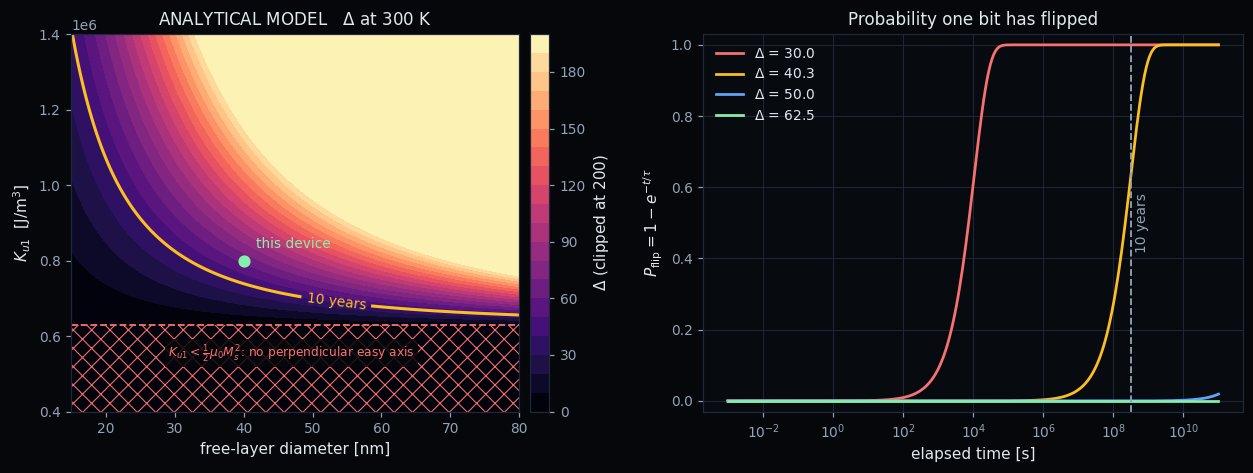

In [4]:
diameter_axis = np.linspace(15.0, 80.0, 160)
ku_axis = np.linspace(4.0e5, 1.4e6, 160)
diameter_grid, ku_grid = np.meshgrid(diameter_axis, ku_axis)

# Same K_eff and Delta as the scalar helpers, evaluated over the whole grid.
shape_term = 0.5 * MU_0 * MS_A_PER_M**2
keff_grid = np.maximum(0.0, ku_grid - shape_term)
volume_grid = (np.pi / 4.0) * (diameter_grid * 1e-9) ** 2 * (FREE_THICKNESS_NM * 1e-9)
delta_grid = keff_grid * volume_grid / (BOLTZMANN * TEMPERATURE_K)

# Cross-check one grid point against the audited scalar path.
probe = thermal_stability(
    effective_anisotropy(1.0e6, MS_A_PER_M)["effective_j_per_m3"],
    free_layer_volume_m3(50.0, 50.0, FREE_THICKNESS_NM),
    TEMPERATURE_K,
)
grid_probe = float(np.interp(50.0, diameter_axis, delta_grid[np.argmin(np.abs(ku_axis - 1.0e6))]))
assert abs(grid_probe - float(probe["delta"])) / float(probe["delta"]) < 0.02

fig, (ax_map, ax_flip) = plt.subplots(1, 2, figsize=(11.5, 4.4))

levels = np.arange(0.0, 201.0, 10.0)
filled = ax_map.contourf(diameter_grid, ku_grid, np.clip(delta_grid, 0, 200), levels=levels,
                         cmap="magma")
ten_year = ax_map.contour(diameter_grid, ku_grid, delta_grid, levels=[DELTA_TEN_YEAR],
                          colors=[WARN], linewidths=2.0)
ax_map.clabel(ten_year, fmt={DELTA_TEN_YEAR: "10 years"}, fontsize=9, colors=[WARN])
ax_map.contourf(diameter_grid, ku_grid, (keff_grid <= 0).astype(float),
                levels=[0.5, 1.5], colors="none", hatches=["xx"])
ax_map.axhline(shape_term, color=BAD, ls="--", lw=1.2)
ax_map.text(47.0, shape_term * 0.93, r"$K_{u1}<\frac{1}{2}\mu_0M_s^2$: no perpendicular easy axis",
            color=BAD, fontsize=8, va="top", ha="center",
            bbox=dict(facecolor="#05070a", edgecolor="none", alpha=0.85, pad=2.0))
ax_map.plot([DIAMETER_NM], [KU1_J_PER_M3], "o", color=GOOD, ms=7)
ax_map.annotate("this device", (DIAMETER_NM, KU1_J_PER_M3), textcoords="offset points",
                xytext=(8, 8), color=GOOD, fontsize=9)
ax_map.set_xlabel("free-layer diameter [nm]")
ax_map.set_ylabel(r"$K_{u1}$  [J/m$^3$]")
ax_map.set_title(r"ANALYTICAL MODEL   $\Delta$ at 300 K")
ax_map.grid(False)
bar = fig.colorbar(filled, ax=ax_map, pad=0.02)
bar.set_label(r"$\Delta$ (clipped at 200)", color=INK)
bar.ax.tick_params(colors=MUTED)

elapsed = np.logspace(-3, 11, 300)
for delta_value, color in zip([30.0, DELTA_TEN_YEAR, 50.0, 62.5],
                              [BAD, WARN, ACCENT, GOOD]):
    flip = np.array([
        float(retention_from_delta(delta_value, elapsed_seconds=float(t))["flip_probability"])
        for t in elapsed
    ])
    label = r"$\Delta$ = %.1f" % delta_value
    ax_flip.semilogx(elapsed, flip, color=color, label=label)
ax_flip.axvline(TEN_YEAR_SECONDS, color=MUTED, ls="--", lw=1.2)
ax_flip.text(TEN_YEAR_SECONDS * 1.3, 0.5, "10 years", color=MUTED, fontsize=9, rotation=90,
             va="center")
ax_flip.set_xlabel("elapsed time [s]")
ax_flip.set_ylabel(r"$P_\mathrm{flip}=1-e^{-t/\tau}$")
ax_flip.set_title("Probability one bit has flipped")
ax_flip.set_ylim(-0.03, 1.03)
ax_flip.legend(loc="upper left")

fig.tight_layout()
save(fig, "retention_design_map.png")
plt.show()

## Data leak through the barrier

The leakage current is an integral of two competing factors over energy:

- $T(E)$, the transmission of the exact 1D barrier, which grows steeply with $E$;
- $N(E)$, the Tsu–Esaki supply function, which is only non-zero where the two
  electrodes disagree about occupancy — a window of width $qV$ near $E_F$.

Their product is the integrand, and it is sharply peaked. Almost all of the leak
comes from a narrow band of energies just below the Fermi level, which is why the
current is exponentially sensitive to barrier thickness but only linearly
sensitive to the read bias at small $V$.

At exactly zero bias the supply function vanishes everywhere and the net current
is zero, as it must be: two electrodes in equilibrium carry no net current even
though electrons are tunneling both ways.

saved notebooks/figures/leakage_integrand.png


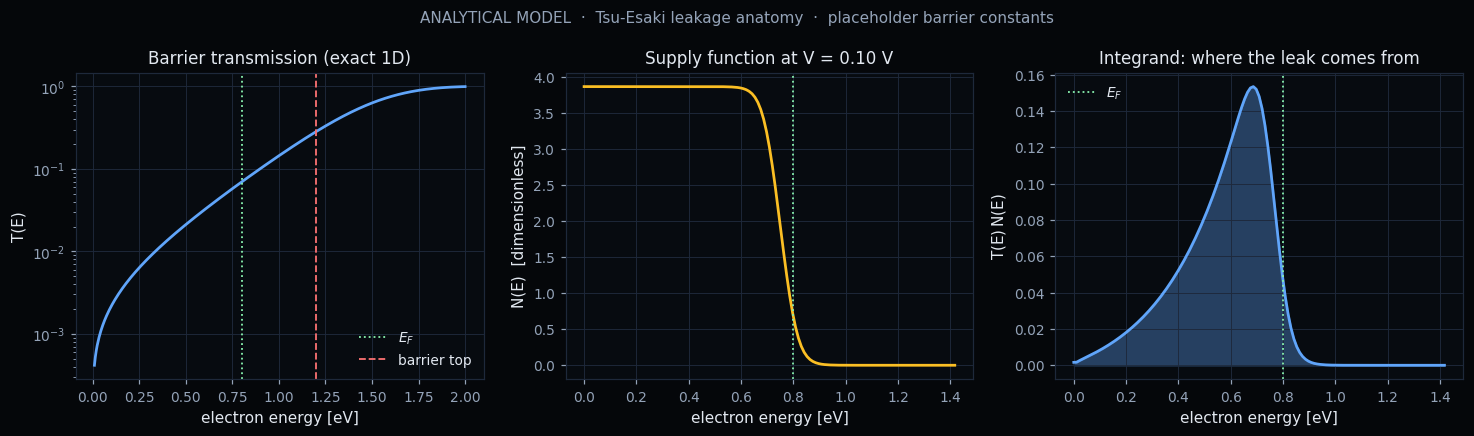

integrand peaks at E = 0.686 eV, i.e. 0.114 eV below E_F
J = 8.642e+10 A/m^2 from this spectrum
J at exactly zero bias = 0 A/m^2 (equilibrium, no net current)


In [5]:
spectrum = tunnel_current_density(
    barrier_thickness_nm=BARRIER_THICKNESS_NM,
    barrier_height_ev=BARRIER_HEIGHT_EV,
    effective_mass_ratio=EFFECTIVE_MASS_RATIO,
    bias_volts=READ_BIAS_V,
    temperature_k=TEMPERATURE_K,
    fermi_ev=FERMI_EV,
    energy_samples=129,
)
energies = spectrum["energies_ev"]
integrand = spectrum["transmission"] * spectrum["supply"]

# A finely sampled T(E) for the smooth curve, independent of the integration grid.
fine_energies = np.linspace(0.01, BARRIER_HEIGHT_EV + 0.8, 400)
fine_transmission = np.array([
    transmission(
        barrier_thickness_nm=BARRIER_THICKNESS_NM,
        barrier_height_ev=BARRIER_HEIGHT_EV,
        electron_energy_ev=float(energy),
        effective_mass_ratio=EFFECTIVE_MASS_RATIO,
        bias_volts=READ_BIAS_V,
        temperature_k=TEMPERATURE_K,
    )["transmission"]
    for energy in fine_energies
])

fig, (ax_t, ax_n, ax_prod) = plt.subplots(1, 3, figsize=(13.5, 4.0))

ax_t.semilogy(fine_energies, np.maximum(fine_transmission, 1e-20), color=ACCENT)
ax_t.axvline(FERMI_EV, color=GOOD, ls=":", lw=1.2, label=r"$E_F$")
ax_t.axvline(BARRIER_HEIGHT_EV, color=BAD, ls="--", lw=1.2, label="barrier top")
ax_t.set_xlabel("electron energy [eV]")
ax_t.set_ylabel("T(E)")
ax_t.set_title("Barrier transmission (exact 1D)")
ax_t.legend(loc="lower right")

ax_n.plot(energies, spectrum["supply"], color=WARN)
ax_n.axvline(FERMI_EV, color=GOOD, ls=":", lw=1.2)
ax_n.set_xlabel("electron energy [eV]")
ax_n.set_ylabel("N(E)  [dimensionless]")
ax_n.set_title(r"Supply function at V = %.2f V" % READ_BIAS_V)

ax_prod.fill_between(energies, integrand, color=ACCENT, alpha=0.35)
ax_prod.plot(energies, integrand, color=ACCENT)
ax_prod.axvline(FERMI_EV, color=GOOD, ls=":", lw=1.2, label=r"$E_F$")
ax_prod.set_xlabel("electron energy [eV]")
ax_prod.set_ylabel(r"T(E)$\,$N(E)")
ax_prod.set_title("Integrand: where the leak comes from")
ax_prod.legend(loc="upper left")

fig.suptitle("ANALYTICAL MODEL  ·  Tsu-Esaki leakage anatomy  ·  placeholder barrier constants",
             color=MUTED, fontsize=10)
fig.tight_layout()
save(fig, "leakage_integrand.png")
plt.show()

peak = float(energies[int(np.argmax(integrand))])
print("integrand peaks at E = %.3f eV, i.e. %.3f eV below E_F" % (peak, FERMI_EV - peak))
print("J = %.4g A/m^2 from this spectrum" % spectrum["current_density_a_per_m2"])
zero_bias = tunnel_current_density(BARRIER_THICKNESS_NM, BARRIER_HEIGHT_EV, bias_volts=0.0)
print("J at exactly zero bias = %.3g A/m^2 (equilibrium, no net current)"
      % zero_bias["current_density_a_per_m2"])

saved notebooks/figures/leakage_sensitivities.png


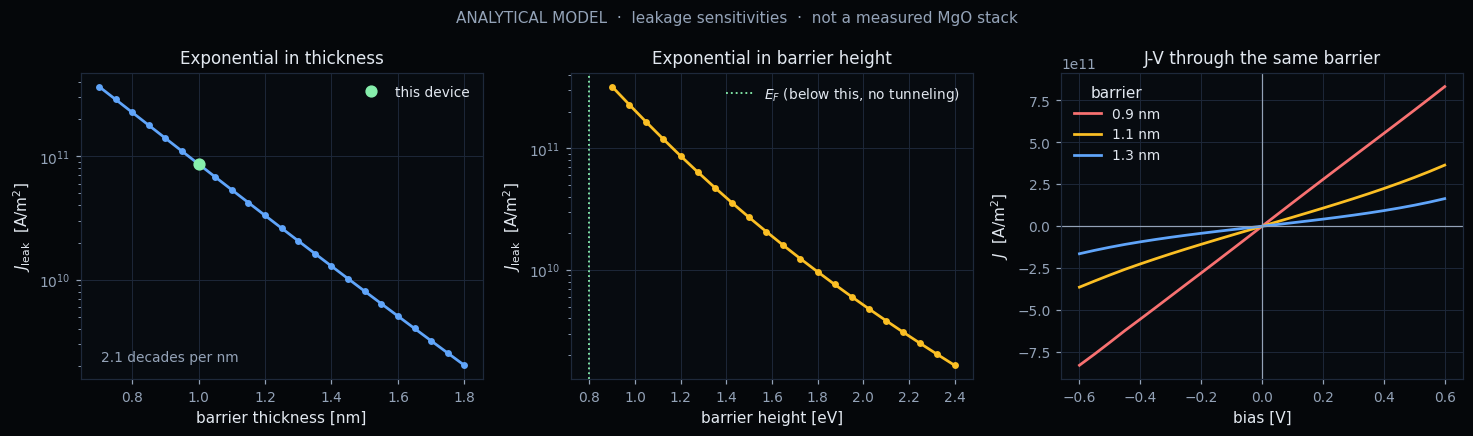

A 0.2 nm thicker barrier cuts the leak by 2.6x


In [6]:
thickness_axis = np.linspace(0.7, 1.8, 23)
j_vs_thickness = leakage_sweep(
    thickness_axis,
    sweep="barrier_thickness_nm",
    barrier_height_ev=BARRIER_HEIGHT_EV,
    effective_mass_ratio=EFFECTIVE_MASS_RATIO,
    bias_volts=READ_BIAS_V,
    temperature_k=TEMPERATURE_K,
    fermi_ev=FERMI_EV,
)

height_axis = np.linspace(0.9, 2.4, 21)
j_vs_height = leakage_sweep(
    height_axis,
    sweep="barrier_height_ev",
    barrier_thickness_nm=BARRIER_THICKNESS_NM,
    effective_mass_ratio=EFFECTIVE_MASS_RATIO,
    bias_volts=READ_BIAS_V,
    temperature_k=TEMPERATURE_K,
    fermi_ev=FERMI_EV,
)

bias_axis = np.linspace(-0.6, 0.6, 25)
jv_curves = {}
for thickness in (0.9, 1.1, 1.3):
    jv_curves[thickness] = leakage_sweep(
        bias_axis,
        sweep="bias_volts",
        barrier_thickness_nm=thickness,
        barrier_height_ev=BARRIER_HEIGHT_EV,
        effective_mass_ratio=EFFECTIVE_MASS_RATIO,
        temperature_k=TEMPERATURE_K,
        fermi_ev=FERMI_EV,
    )

fig, (ax_d, ax_h, ax_jv) = plt.subplots(1, 3, figsize=(13.5, 4.0))

ax_d.semilogy(thickness_axis, j_vs_thickness, "o-", color=ACCENT, ms=3.5)
ax_d.plot([BARRIER_THICKNESS_NM], [leak["current_density_a_per_m2"]], "o", color=GOOD, ms=7,
          label="this device")
ax_d.set_xlabel("barrier thickness [nm]")
ax_d.set_ylabel(r"$J_\mathrm{leak}$  [A/m$^2$]")
ax_d.set_title("Exponential in thickness")
ax_d.legend(loc="upper right")

decades_per_nm = -np.polyfit(thickness_axis, np.log10(j_vs_thickness), 1)[0]
ax_d.text(0.05, 0.06, "%.1f decades per nm" % decades_per_nm, transform=ax_d.transAxes,
          color=MUTED, fontsize=9)

ax_h.semilogy(height_axis, j_vs_height, "o-", color=WARN, ms=3.5)
ax_h.axvline(FERMI_EV, color=GOOD, ls=":", lw=1.2, label=r"$E_F$ (below this, no tunneling)")
ax_h.set_xlabel("barrier height [eV]")
ax_h.set_ylabel(r"$J_\mathrm{leak}$  [A/m$^2$]")
ax_h.set_title("Exponential in barrier height")
ax_h.legend(loc="upper right")

for (thickness, curve), color in zip(sorted(jv_curves.items()), [BAD, WARN, ACCENT]):
    ax_jv.plot(bias_axis, curve, color=color, label="%.1f nm" % thickness)
ax_jv.axhline(0.0, color=MUTED, lw=0.8)
ax_jv.axvline(0.0, color=MUTED, lw=0.8)
ax_jv.set_xlabel("bias [V]")
ax_jv.set_ylabel(r"$J$  [A/m$^2$]")
ax_jv.set_title("J-V through the same barrier")
ax_jv.legend(loc="upper left", title="barrier")

fig.suptitle("ANALYTICAL MODEL  ·  leakage sensitivities  ·  not a measured MgO stack",
             color=MUTED, fontsize=10)
fig.tight_layout()
save(fig, "leakage_sensitivities.png")
plt.show()

print("A 0.2 nm thicker barrier cuts the leak by %.1fx"
      % (10.0 ** (0.2 * decades_per_nm)))

## Where the two constraints collide

Retention and leakage are not independent, because both scale with the junction
footprint. Widening the pillar multiplies the free-layer volume, so $\Delta$ and
$\tau$ climb — but it also multiplies the tunneling area, so the leakage
*current per bit* climbs by the same factor $D^2$.

That leaves a bounded design window: wide enough that the bit survives ten years,
narrow enough that the leak stays inside a current budget. The barrier thickness
shifts the leakage wall without touching retention at all, which is what makes it
the useful independent knob.

The budget line below is an arbitrary illustrative value, not a specification.

saved notebooks/figures/retention_vs_leakage_window.png


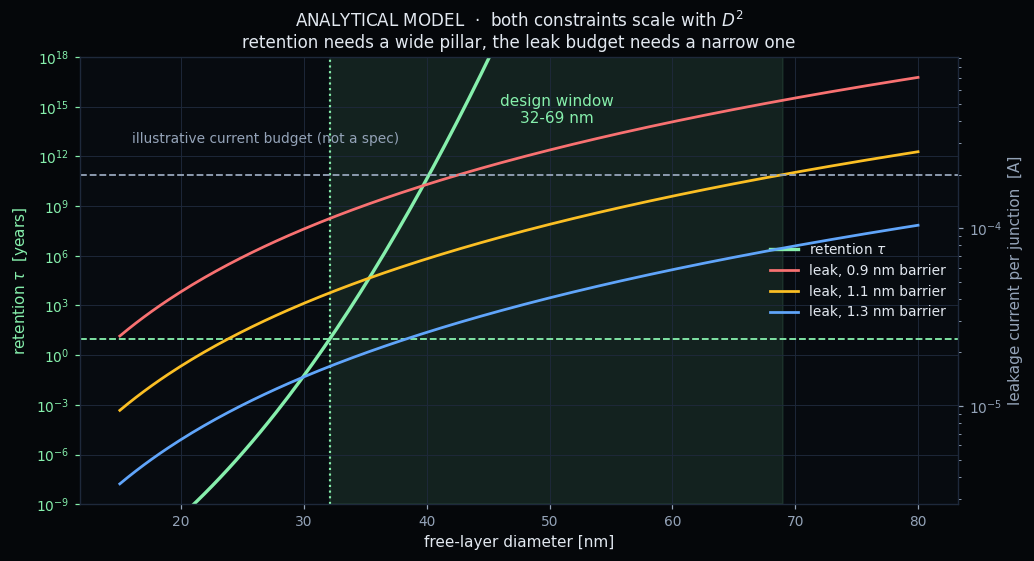

10-year retention needs D >= 32.1 nm
window is 37 nm wide at a 1.1 nm barrier


In [7]:
# Illustrative only, and deliberately set on the scale of the currents this model
# actually produces (~1e-4 A at 0.1 V) rather than on a number invented in advance.
# An MTJ is a low-resistance device, so its read current is intrinsically large;
# this is not a standby-leakage specification.
LEAKAGE_BUDGET_A = 2e-4

diameters = np.linspace(15.0, 80.0, 200)
areas = (np.pi / 4.0) * (diameters * 1e-9) ** 2
volumes = areas * (FREE_THICKNESS_NM * 1e-9)
tau_years = retention_from_delta(
    thermal_stability(anisotropy["effective_j_per_m3"], volumes, TEMPERATURE_K)["delta"]
)["tau_years"]

# J does not depend on the footprint, so one evaluation per barrier is enough.
barriers = {}
for thickness in (0.9, 1.1, 1.3):
    j = tunnel_current_density(
        barrier_thickness_nm=thickness,
        barrier_height_ev=BARRIER_HEIGHT_EV,
        effective_mass_ratio=EFFECTIVE_MASS_RATIO,
        bias_volts=READ_BIAS_V,
        temperature_k=TEMPERATURE_K,
        fermi_ev=FERMI_EV,
    )["current_density_a_per_m2"]
    barriers[thickness] = j * areas

fig, ax_ret = plt.subplots(figsize=(9.5, 5.2))

ax_ret.semilogy(diameters, tau_years, color=GOOD, lw=2.2, label=r"retention $\tau$")
ax_ret.axhline(10.0, color=GOOD, ls="--", lw=1.2)
ax_ret.set_xlabel("free-layer diameter [nm]")
ax_ret.set_ylabel(r"retention $\tau$  [years]", color=GOOD)
ax_ret.tick_params(axis="y", colors=GOOD)
ax_ret.set_ylim(1e-9, 1e18)

d_min = float(np.interp(10.0, tau_years, diameters))
ax_ret.axvline(d_min, color=GOOD, ls=":", lw=1.4)

ax_leak = ax_ret.twinx()
for (thickness, current), color in zip(sorted(barriers.items()), [BAD, WARN, ACCENT]):
    ax_leak.semilogy(diameters, current, color=color, lw=1.8,
                     label="leak, %.1f nm barrier" % thickness)
ax_leak.axhline(LEAKAGE_BUDGET_A, color=MUTED, ls="--", lw=1.2)
ax_leak.text(16.0, LEAKAGE_BUDGET_A * 1.5, "illustrative current budget (not a spec)",
             color=MUTED, fontsize=9)
ax_leak.set_ylabel(r"leakage current per junction  [A]", color=MUTED)
ax_leak.grid(False)

# The window closes where the chosen barrier crosses the budget.
reference_thickness = 1.1
d_max = float(np.interp(LEAKAGE_BUDGET_A, barriers[reference_thickness], diameters))
if d_max > d_min:
    ax_ret.axvspan(d_min, d_max, color=GOOD, alpha=0.10)
    ax_ret.text((d_min + d_max) / 2.0, 1e14,
                "design window\n%.0f-%.0f nm" % (d_min, d_max),
                color=GOOD, fontsize=10, ha="center")
    verdict = "window is %.0f nm wide at a %.1f nm barrier" % (d_max - d_min, reference_thickness)
else:
    verdict = "no window at a %.1f nm barrier: thicken it" % reference_thickness

handles = ax_ret.get_legend_handles_labels()[0] + ax_leak.get_legend_handles_labels()[0]
labels = ax_ret.get_legend_handles_labels()[1] + ax_leak.get_legend_handles_labels()[1]
ax_ret.legend(handles, labels, loc="center right")
ax_ret.set_title("ANALYTICAL MODEL  ·  both constraints scale with $D^2$\n"
                 "retention needs a wide pillar, the leak budget needs a narrow one",
                 fontsize=11)

fig.tight_layout()
save(fig, "retention_vs_leakage_window.png")
plt.show()

print("10-year retention needs D >= %.1f nm" % d_min)
print("%s" % verdict)

## Agreement with the Twin app

The cell below re-runs the golden values exported from the JavaScript that the web
dashboard uses. If this notebook and the app ever disagree, this fails loudly
rather than producing two plausible but different sets of figures.

In [8]:
import json

golden = json.loads((REPO_ROOT / "backend" / "tests" / "data" / "device_chain_golden.json").read_text())
checks = 0

for case in golden["retention"]:
    expected = case["tauSeconds"]
    actual = float(retention_from_delta(float(case["delta"]))["tau_seconds"])
    if expected == "Infinity":
        assert np.isinf(actual), case
    else:
        assert abs(actual - expected) <= 1e-9 * abs(expected), case
    checks += 1

for case in golden["leakage"]:
    args = case["input"]
    actual = tunnel_current_density(
        barrier_thickness_nm=args["barrierThicknessNm"],
        barrier_height_ev=args["barrierHeightEv"],
        effective_mass_ratio=args["effectiveMassRatio"],
        bias_volts=args["biasVolts"],
        temperature_k=args["temperatureK"],
        fermi_ev=args["fermiEv"],
        energy_samples=args["energySamples"],
    )["current_density_a_per_m2"]
    expected = case["currentDensityAPerM2"]
    assert abs(actual - expected) <= 1e-9 * abs(expected), case
    checks += 1

for case in golden["transmission"]:
    args = case["input"]
    actual = transmission(
        barrier_thickness_nm=args["barrierThicknessNm"],
        barrier_height_ev=args["barrierHeightEv"],
        electron_energy_ev=args["electronEnergyEv"],
        effective_mass_ratio=args["effectiveMassRatio"],
        bias_volts=args["biasVolts"],
        temperature_k=args["temperatureK"],
    )["transmission"]
    expected = case["transmission"]
    assert abs(actual - expected) <= 1e-9 * abs(expected), case
    checks += 1

print("%d golden values reproduced from the JavaScript device chain" % checks)
print("source: %s" % golden["source"])
print()
print("Reminders:")
print("- retention and leakage here are ANALYTICAL MODELS, not measurements")
print("- barrier height, effective mass, and Fermi level are placeholders")
print("- magnetization dynamics come from the python_micromagnetic mesh solver, not this notebook")

19 golden values reproduced from the JavaScript device chain
source: apps/website/js/simulator/lib/devicePhysics.js

Reminders:
- retention and leakage here are ANALYTICAL MODELS, not measurements
- barrier height, effective mass, and Fermi level are placeholders
- magnetization dynamics come from the python_micromagnetic mesh solver, not this notebook
